# Merge the meteo products and overview (2004-2025)

**notebook version**: `1` (21 Jul 2026)

## ℹ️ About this notebook

The capstone of the `30_PRODUCTS` stage. It reads the seven per-variable products written by
notebooks `01`-`07`, joins them onto one continuous 30MIN `TIMESTAMP_MID` index, writes a single
merged file, and draws a compact overview figure for each variable.

Nothing is computed or corrected here — the values are exactly what `01`-`07` exported. This
notebook only **collects** them and **looks** at them, so it must run after `01`-`07`.

**Outputs:**

- `99_METEO_MERGED_2004-2025.parquet` / `.csv` — every product value and its provenance flag in
  one wide table.
- One overview figure per variable (displayed inline): daily-mean time series, diurnal
  fingerprint, annual cycle, and the provenance flag composition per year (or the value
  distribution where a variable carries no flag).

## 📇 Data sources

All inputs are the parquet products in the external data folder, written by earlier notebooks of
this stage. `SW_IN`/`TA`/`PPFD_IN` keep their `_gfXG` (gap-filled) columns; `RH` carries a
`_MISSING` provenance flag; `PA`/`LW_IN` are exported as measured with no flag; `VPD` is computed.

| notebook | value column | flag column | span |
|---|---|---|---|
| `01` `SW_IN` | `SW_IN_T1_47_1_gfXG` | `FLAG_SW_IN_T1_47_1_ISFILLED` | 2004-2025 |
| `02` `TA` | `TA_T1_47_1_gfXG` | `FLAG_TA_T1_47_1_ISFILLED` | 2004-2025 |
| `03` `PPFD_IN` | `PPFD_IN_T1_47_1_gfXG` | `FLAG_PPFD_IN_T1_47_1_ISFILLED` | 2004-2025 |
| `04` `RH` | `RH_T1_47_1` | `FLAG_RH_T1_47_1_MISSING` | 2004-2025 |
| `05` `PA` | `PA_T1_47_1` | — | 2005-2025 |
| `06` `LW_IN` | `LW_IN_T1_47_1` | — | 2005-2025 |
| `07` `VPD` | `VPD_T1_47_1` | `FLAG_VPD_T1_47_1_ISFILLED` | 2004-2025 |

`PA` and `LW_IN` begin in September 2005, so they are `NaN` before then in the merged table.

## ⚙️ Settings

In [1]:
from pathlib import Path

# Products live in the external (untracked) data folder, alongside where the merged file is written.
PRODDIR = Path(r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
               r"\workflow\10_METEO\30_PRODUCTS")

OUTNAME = "99_METEO_MERGED_2004-2025"

# (file stem, value column, flag column or None, short name, units)
PRODUCTS = [
    ("01_METEO_SW_IN_GAPFILLED_2004-2025",   "SW_IN_T1_47_1_gfXG",   "FLAG_SW_IN_T1_47_1_ISFILLED",   "SW_IN",   "W m$^{-2}$"),
    ("02_METEO_TA_GAPFILLED_2004-2025",      "TA_T1_47_1_gfXG",      "FLAG_TA_T1_47_1_ISFILLED",      "TA",      "°C"),
    ("03_METEO_PPFD_IN_GAPFILLED_2004-2025", "PPFD_IN_T1_47_1_gfXG", "FLAG_PPFD_IN_T1_47_1_ISFILLED", "PPFD_IN", "µmol m$^{-2}$ s$^{-1}$"),
    ("04_METEO_RH_CORRECTED_2004-2025",      "RH_T1_47_1",           "FLAG_RH_T1_47_1_MISSING",       "RH",      "%"),
    ("05_METEO_PA_2005-2025",                "PA_T1_47_1",           None,                            "PA",      "kPa"),
    ("06_METEO_LW_IN_2005-2025",             "LW_IN_T1_47_1",        None,                            "LW_IN",   "W m$^{-2}$"),
    ("07_METEO_VPD_2004-2025",               "VPD_T1_47_1",          "FLAG_VPD_T1_47_1_ISFILLED",     "VPD",     "kPa"),
]

# Short labels for the provenance-flag legend. Codes differ per variable (see the source notebooks);
# unlisted codes fall back to "flag N".
FLAG_LABELS = {
    "SW_IN":   {0: "measured", 1: "model", 2: "fallback", 3: "night 0", 4: "interp"},
    "TA":      {0: "measured", 1: "model", 2: "fallback", 4: "interp"},
    "PPFD_IN": {0: "measured", 1: "model", 2: "fallback", 3: "night 0", 4: "interp"},
    "RH":      {0: "measured", 1: "never", 2: "removed", 3: "NABEL", 4: "Lägern"},
    "VPD":     {0: "measured", 5: "TA filled", 6: "RH NABEL", 7: "RH Lägern"},
}
EXPORT_FORMATS = ("parquet", "csv")

### Imports

In [2]:
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

import diive as dv

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 1000)
print(f"Last run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"pandas v{pd.__version__}, diive v{dv.__version__ if hasattr(dv, '__version__') else '?'}")

Last run: 2026-07-21 02:25:11
pandas v3.0.3, diive v0.91.0


## ⬇️ Load and merge

In [3]:
frames = []
for _stem, _vcol, _fcol, _short, _units in PRODUCTS:
    _cols = [_vcol] + ([_fcol] if _fcol else [])
    _df = pd.read_parquet(PRODDIR / f"{_stem}.parquet")[_cols]
    print(f"{_short:<8} {_stem:<40} {len(_df):>7,} rows  {_df.index[0]} -> {_df.index[-1]}")
    frames.append(_df)

merged = pd.concat(frames, axis=1)
merged.index.name = frames[0].index.name
print(f"\nMerged: {len(merged):,} rows x {merged.shape[1]} columns, "
      f"{merged.index[0]} -> {merged.index[-1]} ({merged.index.name})")
merged.head()

SW_IN    01_METEO_SW_IN_GAPFILLED_2004-2025       385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00
TA       02_METEO_TA_GAPFILLED_2004-2025          385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00
PPFD_IN  03_METEO_PPFD_IN_GAPFILLED_2004-2025     385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00
RH       04_METEO_RH_CORRECTED_2004-2025          385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00
PA       05_METEO_PA_2005-2025                    356,448 rows  2005-09-02 00:15:00 -> 2025-12-31 23:45:00
LW_IN    06_METEO_LW_IN_2005-2025                 355,872 rows  2005-09-14 00:15:00 -> 2025-12-31 23:45:00
VPD      07_METEO_VPD_2004-2025                   385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00

Merged: 385,728 rows x 12 columns, 2004-01-01 00:15:00 -> 2025-12-31 23:45:00 (TIMESTAMP_MIDDLE)


,SW_IN_T1_47_1_gfXG,FLAG_SW_IN_T1_47_1_ISFILLED,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED,PPFD_IN_T1_47_1_gfXG,FLAG_PPFD_IN_T1_47_1_ISFILLED,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING,PA_T1_47_1,LW_IN_T1_47_1,VPD_T1_47_1,FLAG_VPD_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,
2004-01-01 00:15:00,0.0,3,6.938439,2,0.0,3,97.718962,3,NaN,NaN,0.022776,6
2004-01-01 00:45:00,0.0,3,6.938439,2,0.0,3,96.918962,3,NaN,NaN,0.030765,6
2004-01-01 01:15:00,0.0,3,8.341139,2,0.0,3,93.552296,3,NaN,NaN,0.070865,6
2004-01-01 01:45:00,0.0,3,8.341139,2,0.0,3,92.652296,3,NaN,NaN,0.080756,6
2004-01-01 02:15:00,0.0,3,8.205807,2,0.0,3,93.985629,3,NaN,NaN,0.065496,6


### Sanity checks

The index must be the continuous 30MIN axis all seven products share, and every expected column
must be present. Missing values are allowed only for `PA`/`LW_IN` before September 2005.

In [4]:
assert merged.index.is_monotonic_increasing and not merged.index.has_duplicates
_diffs = merged.index.to_series().diff().dropna().unique()
assert len(_diffs) == 1 and _diffs[0] == pd.Timedelta('30min'), f"irregular index: {_diffs}"

_expected = [c for _s, v, f, _n, _u in PRODUCTS for c in ([v] + ([f] if f else []))]
assert list(merged.columns) == _expected, "unexpected column set"

# The gap-filled / complete products must have no NaN; PA and LW_IN may before 2005-09.
for _stem, _vcol, _fcol, _short, _units in PRODUCTS:
    _n = int(merged[_vcol].isna().sum())
    _tag = "OK" if (_n == 0 or _short in ("PA", "LW_IN")) else "!! unexpected NaN"
    print(f"  {_short:<8} {_vcol:<22} NaN={_n:>6,}  {_tag}")
print("\nIndex and columns validated.")

  SW_IN    SW_IN_T1_47_1_gfXG     NaN=     0  OK
  TA       TA_T1_47_1_gfXG        NaN=     0  OK
  PPFD_IN  PPFD_IN_T1_47_1_gfXG   NaN=     0  OK
  RH       RH_T1_47_1             NaN=     0  OK
  PA       PA_T1_47_1             NaN=33,290  OK
  LW_IN    LW_IN_T1_47_1          NaN=34,759  OK
  VPD      VPD_T1_47_1            NaN=     0  OK

Index and columns validated.


### Coverage per variable
When each product starts, and how its records break down by provenance flag.

In [5]:
rows = []
for _stem, _vcol, _fcol, _short, _units in PRODUCTS:
    _s = merged[_vcol]
    _first = _s.first_valid_index()
    _row = {"variable": _short, "units": _units.replace('$', '').replace('^', ''),
            "start": _first.date() if _first is not None else None,
            "present_%": round(_s.notna().mean() * 100, 2)}
    if _fcol:
        _fc = merged[_fcol].value_counts(normalize=True).mul(100).round(1)
        _row["flags (% by code)"] = {int(k): v for k, v in _fc.sort_index().items()}
    else:
        _row["flags (% by code)"] = "no flag"
    rows.append(_row)
pd.DataFrame(rows).set_index("variable")

,units,start,present_%,flags (% by code)
variable,,,,
SW_IN,W m{-2},2004-01-01,100.00,"{0: 91.2, 1: 4.5, 2: 0.2, 3: 4.1}"
TA,°C,2004-01-01,100.00,"{0: 95.7, 1: 3.9, 2: 0.4, 4: 0.0}"
PPFD_IN,µmol m{-2} s{-1},2004-01-01,100.00,"{0: 95.7, 1: 2.2, 2: 0.2, 3: 2.0, 4: 0.0}"
RH,%,2004-01-01,100.00,"{0: 95.7, 3: 4.1, 4: 0.2}"
PA,kPa,2005-09-02,91.37,no flag
LW_IN,W m{-2},2005-09-14,90.99,no flag
VPD,kPa,2004-01-01,100.00,"{0: 95.7, 5: 0.0, 6: 4.1, 7: 0.2}"


## 💾 Export the merged file

In [6]:
outpath = PRODDIR / f"{OUTNAME}.parquet"
written = []
for _fmt in EXPORT_FORMATS:
    _p = PRODDIR / f"{OUTNAME}.{_fmt}"
    if _fmt == "parquet":
        merged.to_parquet(_p)
    else:
        merged.to_csv(_p, index=True, na_rep="")  # NaN stays empty so a gap can't read as a value
    written.append(_p)
    print(f"Wrote {_p.name:<40} ({_p.stat().st_size / 1024:>8.0f} KB)")

# Read the parquet back and check it matches, rather than trusting the in-memory frame.
_back = pd.read_parquet(PRODDIR / f"{OUTNAME}.parquet")
assert _back.shape == merged.shape and list(_back.columns) == list(merged.columns)
assert _back.index.equals(merged.index)
print("\nRead back: matches the merged frame.")

Wrote 99_METEO_MERGED_2004-2025.parquet        (   18616 KB)
Wrote 99_METEO_MERGED_2004-2025.csv            (   52588 KB)

Read back: matches the merged frame.


## 📊 Overview figures

One figure per variable, four views:

- **Daily mean** over the whole record, with a 30-day rolling mean.
- **Fingerprint** — the diive `HeatmapDateTime`, date on the vertical axis against time of day, so
  the diurnal cycle and any gaps or shifts are visible at a glance.
- **Annual cycle** — monthly mean ± 1 SD.
- **Provenance flag, % per year** — the stacked composition of the flag codes, or, where a variable
  carries no flag (`PA`, `LW_IN`), the distribution of its 30-min values.

In [7]:
def overview_figure(series, flag, short, units, flag_labels):
    """Draw a four-view overview for one variable and return the figure."""
    fig = plt.figure(figsize=(17, 8.5), dpi=90, layout='constrained')
    gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[1.4, 1.4, 1.0])
    fig.suptitle(f"{short}   [{units}]", fontsize=18, fontweight='bold')

    # Daily mean + 30-day rolling mean
    ax = fig.add_subplot(gs[0, 0:2])
    _d = series.resample('D').mean()
    ax.plot(_d.index, _d.values, lw=0.4, color='#4C72B0', alpha=.55)
    ax.plot(_d.index, _d.rolling(30, center=True).mean().values, lw=1.3, color='#C44E52',
            label='30-day mean')
    ax.set_title('Daily mean', fontsize=11)
    ax.set_ylabel(units)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=.3)

    # Diurnal fingerprint (diive HeatmapDateTime)
    ax = fig.add_subplot(gs[0:2, 2])
    dv.plotting.HeatmapDateTime(series=series).plot(
        ax=ax, cb_digits_after_comma=0,
        format_style=dv.plotting.FormatStyle(title='Fingerprint', title_fontsize=11))

    # Annual cycle: monthly mean +/- SD
    ax = fig.add_subplot(gs[1, 0])
    _g = series.groupby(series.index.month)
    _m, _sd = _g.mean(), _g.std()
    ax.plot(_m.index, _m.values, color='#C44E52', marker='o', ms=3)
    ax.fill_between(_m.index, (_m - _sd).values, (_m + _sd).values, color='#C44E52', alpha=.18)
    ax.set_title('Annual cycle (monthly mean ± SD)', fontsize=11)
    ax.set_xlabel('month')
    ax.set_ylabel(units)
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=.3)

    # Flag composition per year, or the value distribution where there is no flag
    ax = fig.add_subplot(gs[1, 1])
    if flag is not None:
        comp = flag.groupby([flag.index.year, flag]).size().unstack(fill_value=0)
        comp = comp.div(comp.sum(axis=1), axis=0) * 100
        cmap = plt.get_cmap('viridis', max(len(comp.columns), 2))
        bottom = np.zeros(len(comp))
        for j, code in enumerate(comp.columns):
            _lab = flag_labels.get(int(code), f'flag {int(code)}')
            ax.bar(comp.index, comp[code].values, bottom=bottom, width=.9,
                   color=cmap(j), label=f'{int(code)} {_lab}')
            bottom += comp[code].values
        ax.set_title('Provenance flag, % per year', fontsize=11)
        ax.set_ylabel('%')
        ax.set_ylim(0, 100)
        ax.legend(fontsize=7, ncol=2, loc='lower center', framealpha=.9)
    else:
        ax.hist(series.dropna().values, bins=60, color='#55A868', alpha=.85)
        ax.set_title('Distribution of 30-min values (no flag)', fontsize=11)
        ax.set_xlabel(units)
        ax.set_ylabel('count')
    ax.grid(alpha=.3)
    return fig

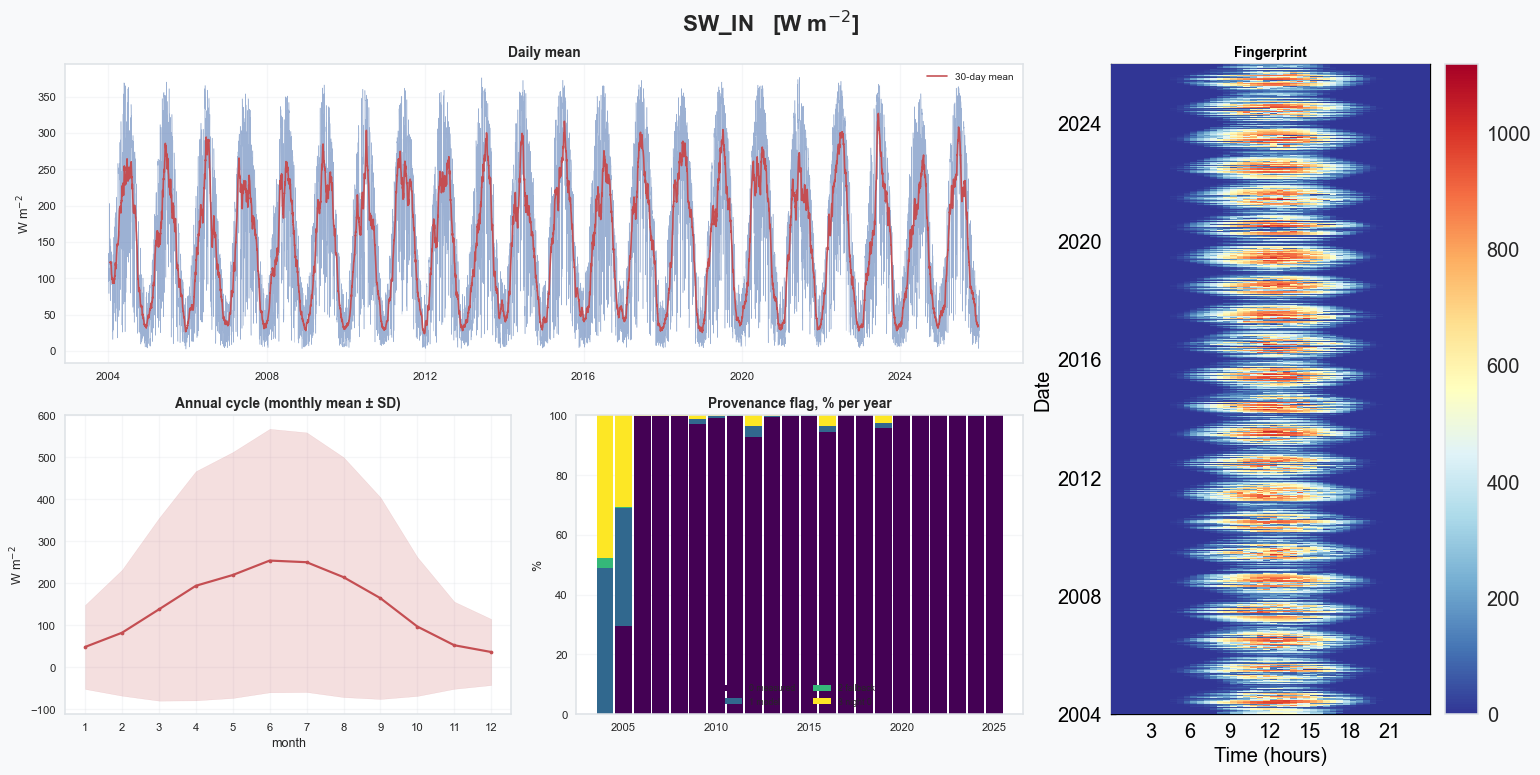

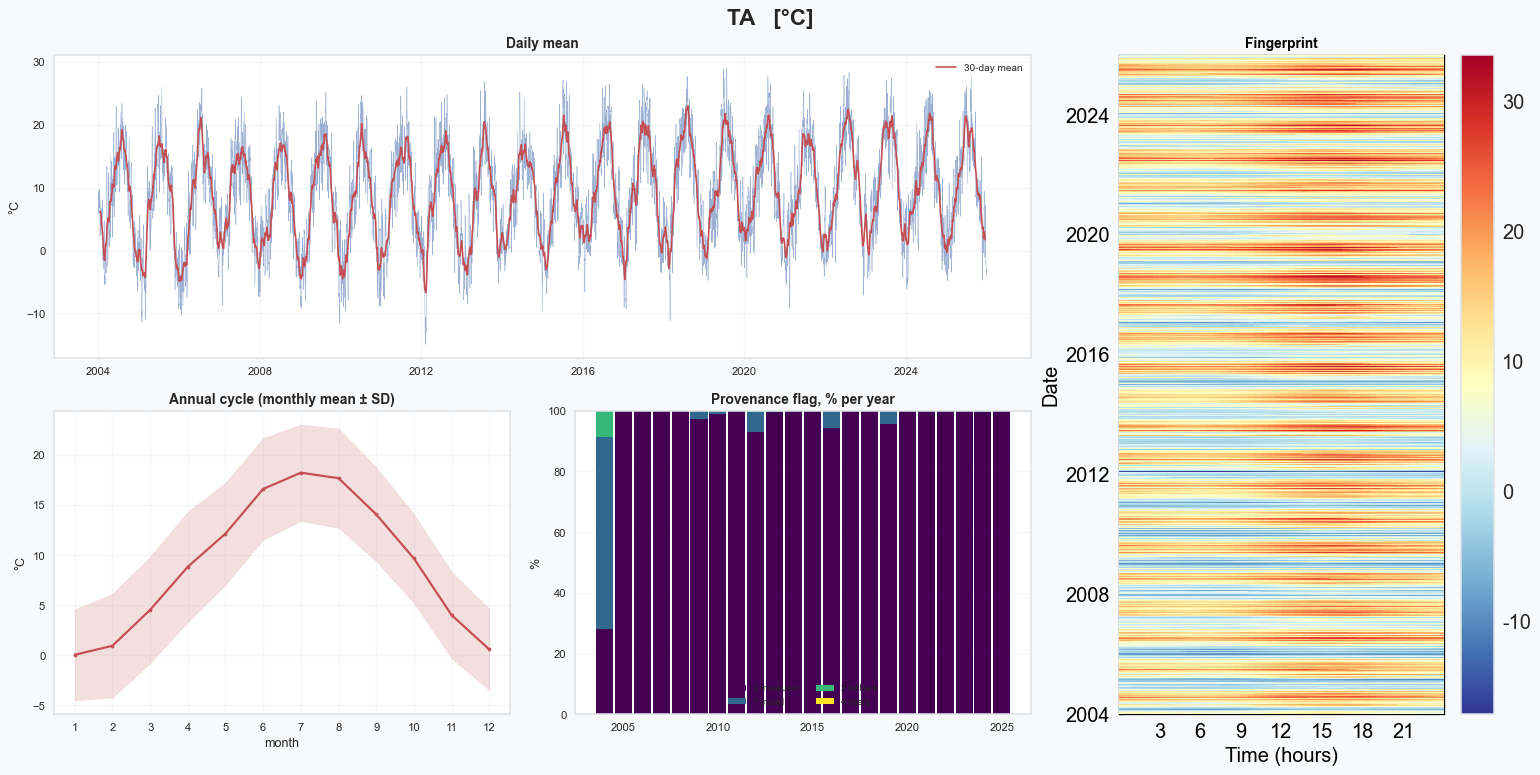

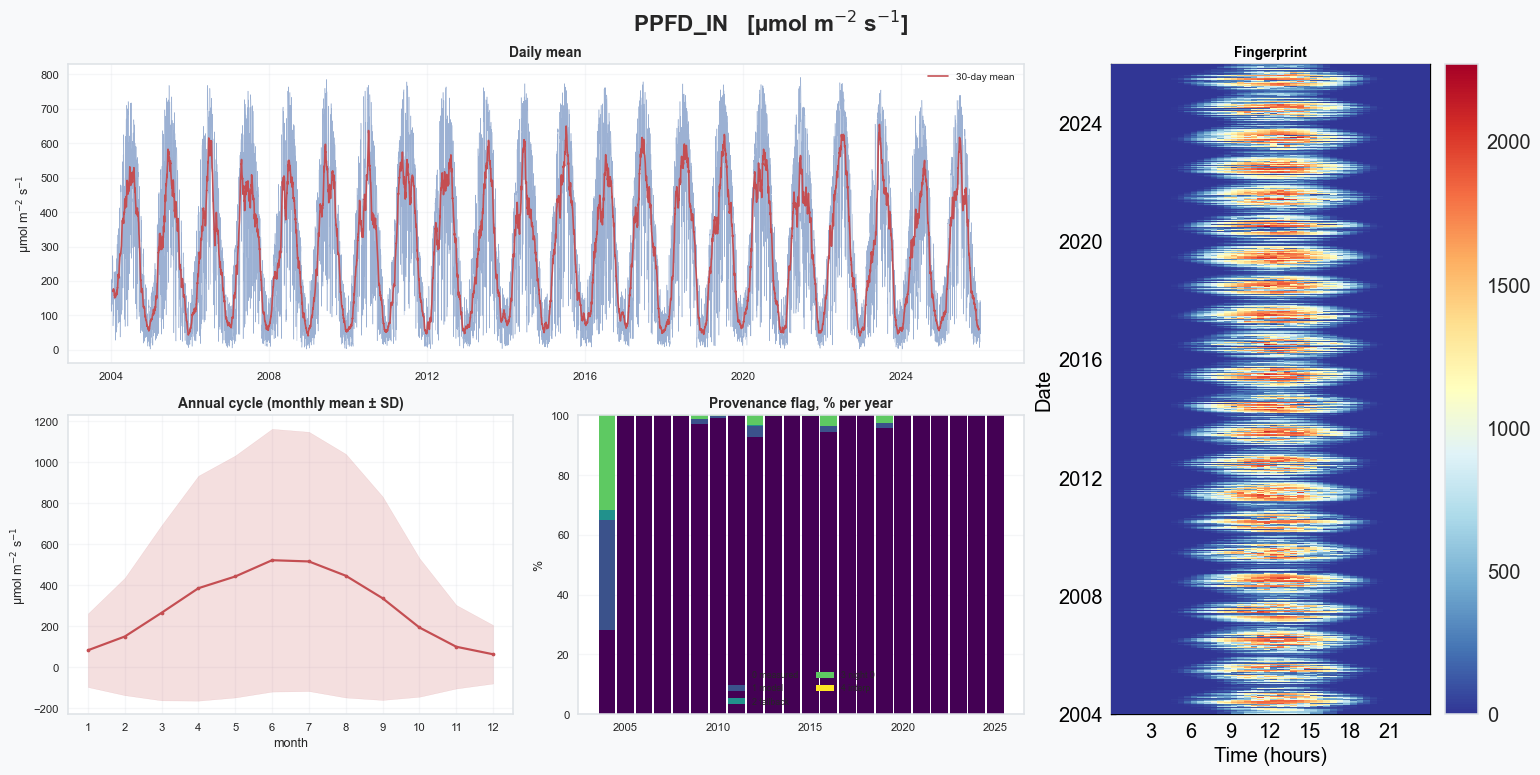

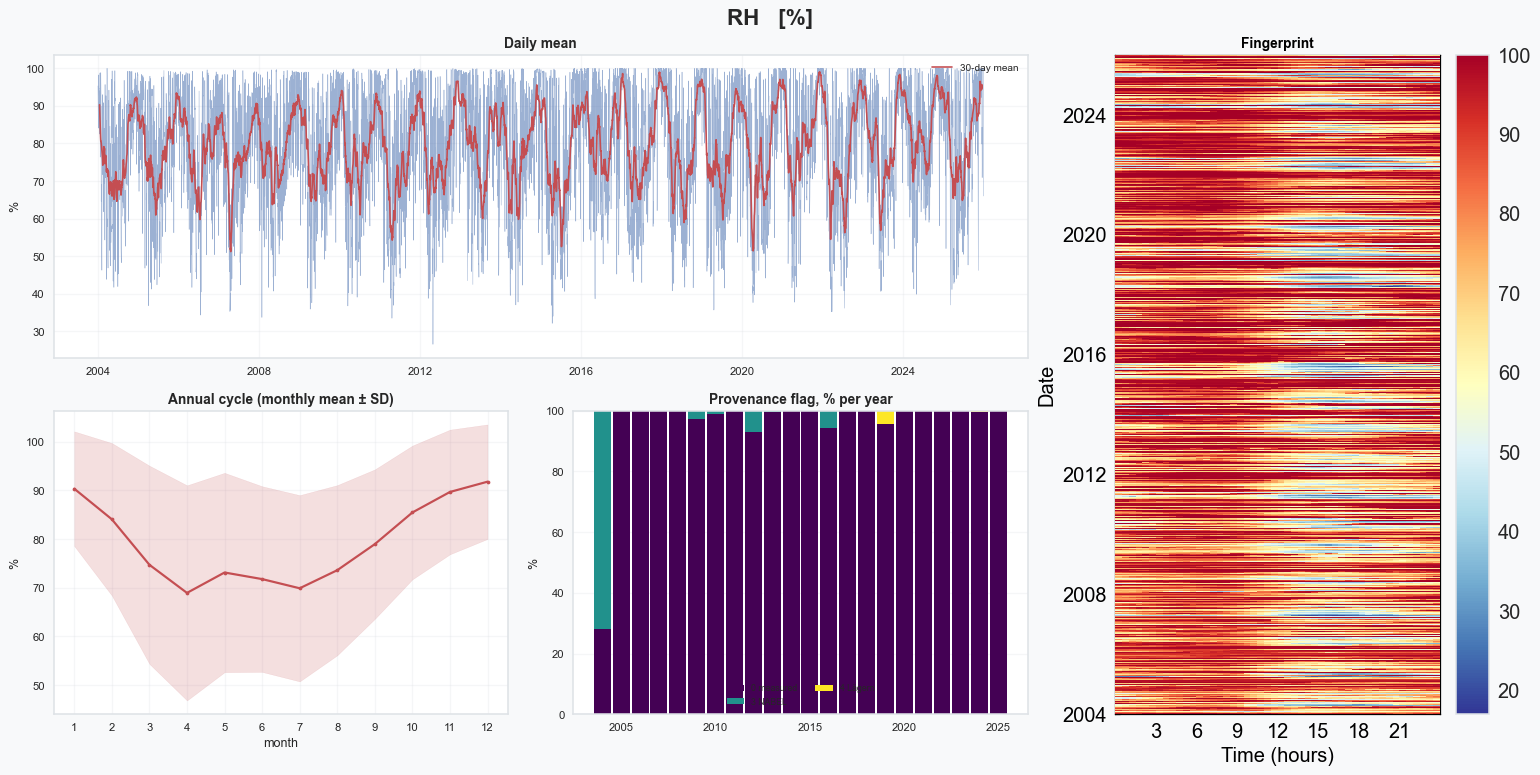

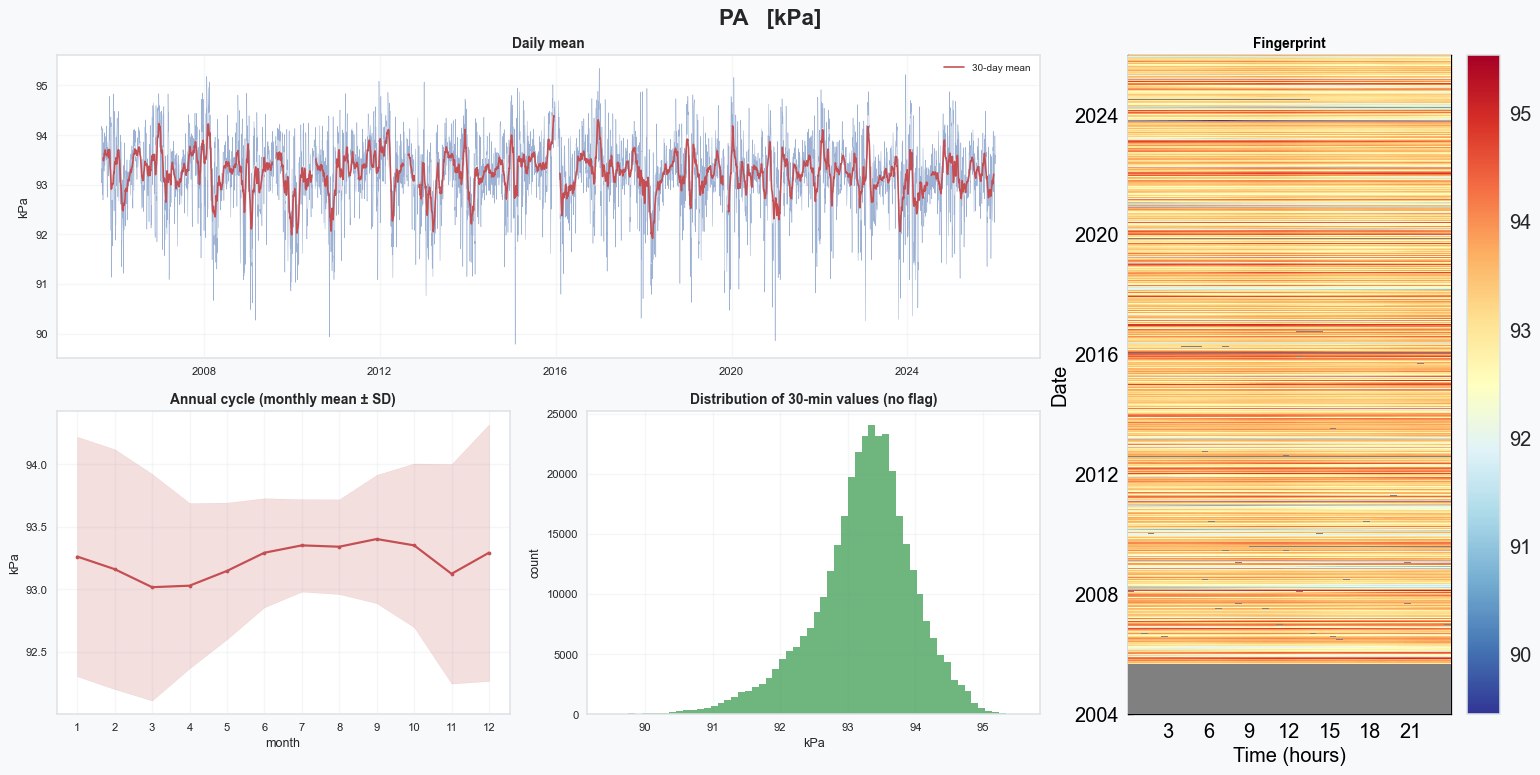

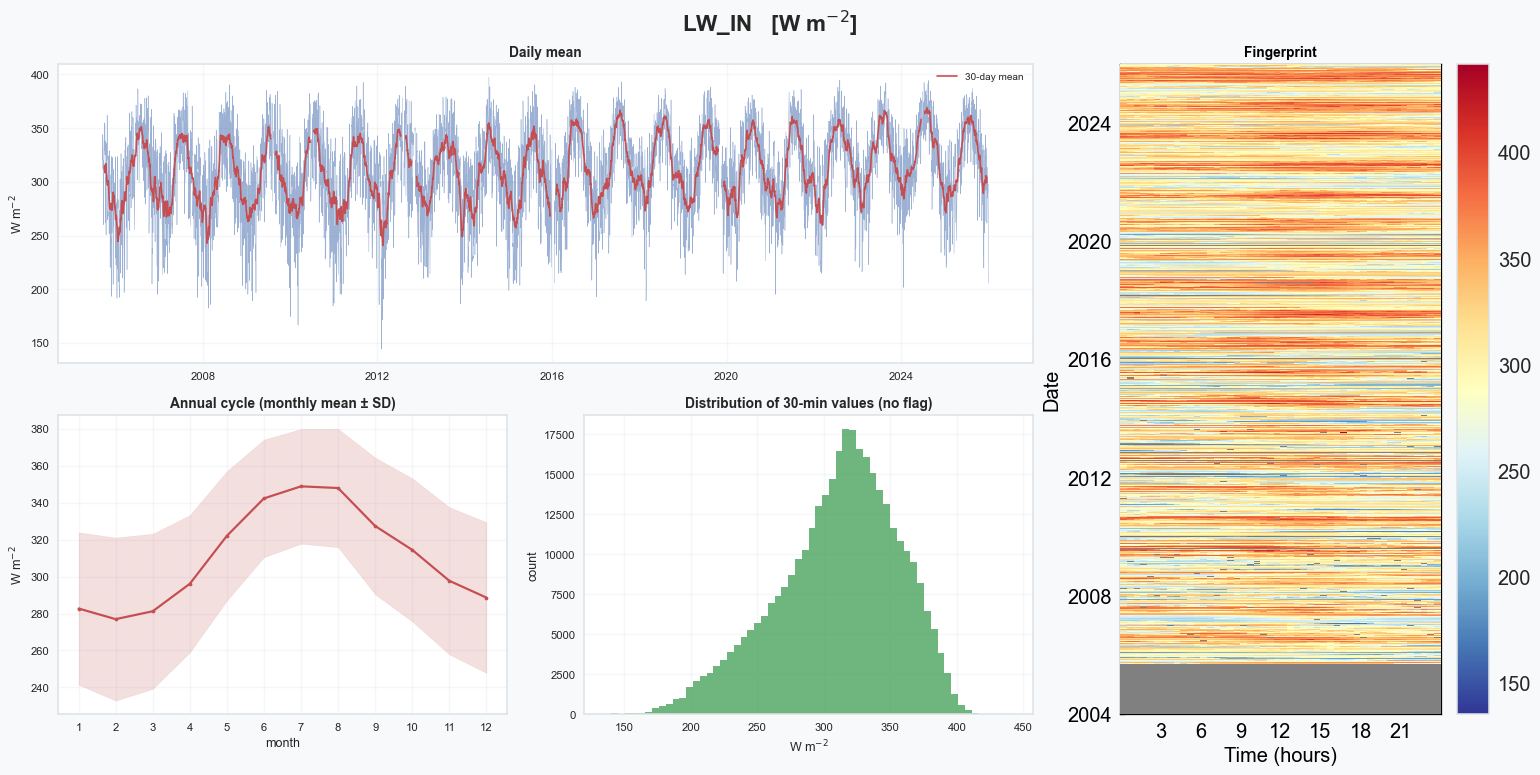

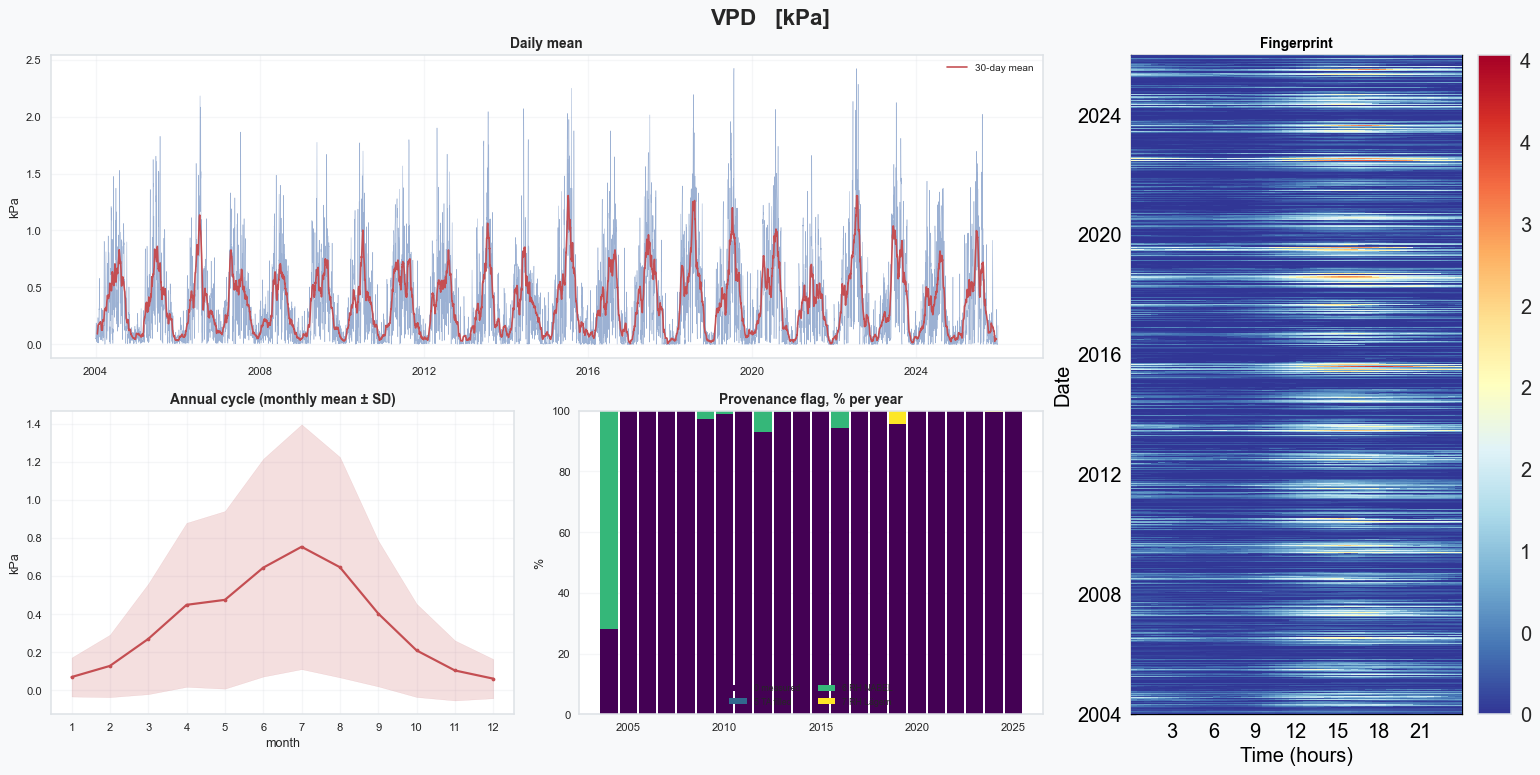

In [8]:
for _stem, _vcol, _fcol, _short, _units in PRODUCTS:
    _flag = merged[_fcol] if _fcol else None
    fig = overview_figure(merged[_vcol], _flag, _short, _units, FLAG_LABELS.get(_short, {}))
    plt.show()

***

In [9]:
print(f"Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Finished: 2026-07-21 02:25:25
